The autoregressive process of order $p$ is denoted AR($p$), and defined by

$$y_t = \phi_1y_{t-1}+\phi_2y_{t-2}...+\phi_py_{t-p}+w_t\text{,}$$

which can be rewritten as

$$y_t = \sum_{j=1}^p\phi_jy_{t-j}+ w_t\text{,}$$

where $\phi_1, \phi_2,..., \phi_p$ are fixed constants and $w_t$ is a random variable with mean 0 and variance $\sigma^2$. 

If the mean, $\mu$, of $y_t$ is not zero, we replace $y_t$ by $y_t-\mu$:

$$y_t-\mu = \sum_{j=1}^p\phi_j(y_{t-j}-\mu)+ w_t$$.

Autoregressive processes have a natural interpretation as the next value observed is a slight perturbation of the most recent observations or, in other words, the current value of the series is linearly dependent upon its previous values, with some random error. This model is called an *autoregressive* (AR) model since $y_t$ is regressed on
itself. 

Regarding autoregressive models past values have an effect on current values. Therefore, it is a natural to use it for analyzing nature, economics, and other processes that vary over time. In an earlier section, we have discussed multiple regression models. They forecast a variable using a linear combination of predictors. In contrast, autoregressive models use a combination of past values of the variable.

A common notation is AR(1) for a autoregressive process, where the current value is based on the immediately preceding value, AR(2) denotes a utoregressive process, where the current value is based on the previous two values. An AR(0) process has no dependence between the terms. It is used e.g. for white noise. 


***

The special case of $p = 1$, the first-order process, is also known as [Markov process](https://en.wikipedia.org/wiki/Markov_chain).

We generate two AR(1) series of the form

$y_t = \phi_1 y_{t-1}+w_t\text{,}$

where one $\phi_1 = 0.6$ and the other $\phi_1 = -0.6$. Notice that  the sign of coefficients in the code is opposite!


In [1]:
%load_ext lab_black

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

In [3]:
# seed random number generator
random.seed(250)

from statsmodels.tsa.arima_process import ArmaProcess

# Plot 1: AR parameter =+0.6
ar1 = np.array([1, -0.6])  # opposite sign!
ma1 = np.array([1])  # we have to include the zero-lag coefficient of 1
AR_object1 = ArmaProcess(ar1, ma1)
simulated_ar1_1 = AR_object1.generate_sample(nsample=100)


# Plot 2: AR parameter = -0.6

ar2 = np.array([1, 0.6])  # opposite sign!
ma2 = np.array([1])  # we have to include the zero-lag coefficient of 1
AR_object2 = ArmaProcess(ar2, ma2)
simulated_ar1_2 = AR_object2.generate_sample(nsample=100)


We plot the two series:


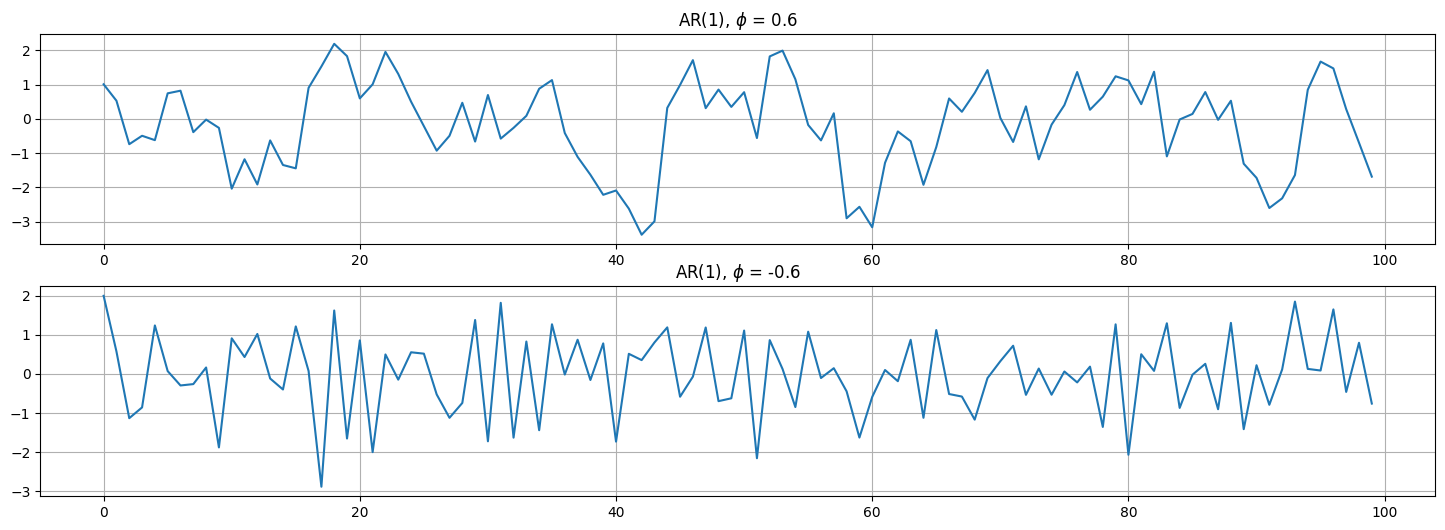

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(18, 6))
ax[0].plot(simulated_ar1_1)
ax[0].set_title("AR(1), $\\phi$ = 0.6")


ax[1].plot(simulated_ar1_2)
ax[1].set_title("AR(1), $\\phi$ = -0.6")

ax[0].grid()
ax[1].grid()
plt.show()


For an AR(1) model the current value $y_t$ of the time series is a function of the last preceding value of the series. We may review the correlational structure by plotting the correlogram. 



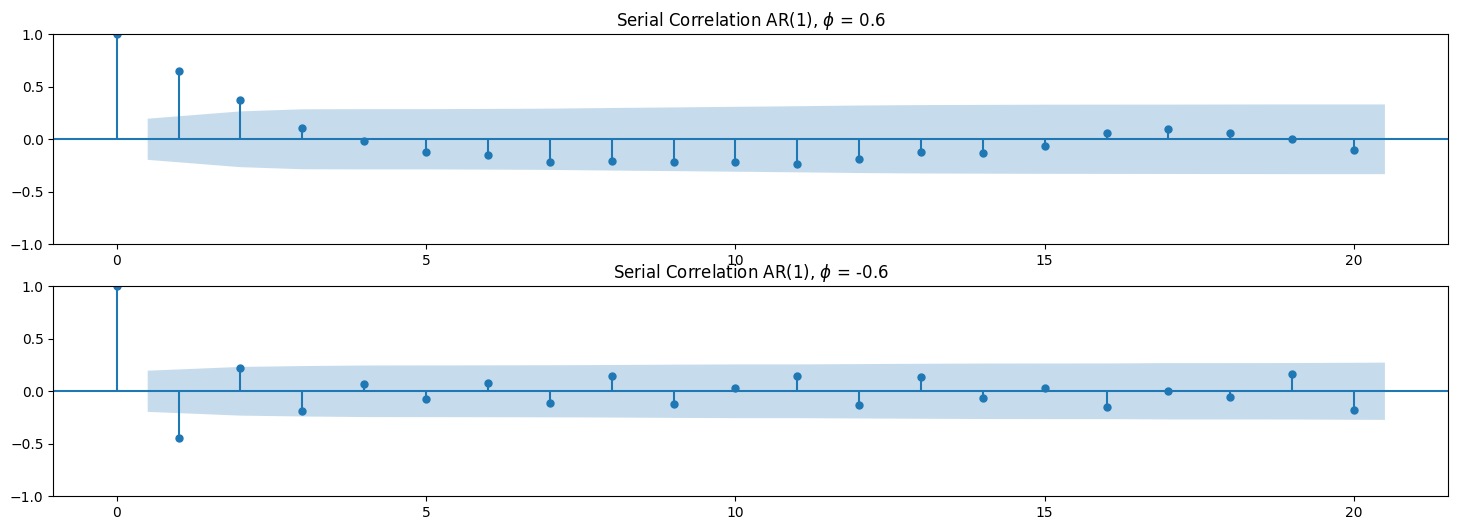

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(2, 1, figsize=(18, 6))

plot_acf(simulated_ar1_1, ax=ax[0])
ax[0].set_title("Serial Correlation AR(1), $\\phi$ = 0.6")

plot_acf(simulated_ar1_2, ax=ax[1])
ax[1].set_title("Serial Correlation AR(1), $\\phi$ = -0.6")

plt.show()

The autocovariance function for the AR series decays exponentially (for $\phi >0$), with a possible sinusoidal variation superimposed (for $\phi <0$). Thus, the correlation drops off faster the greater the value of $k$.

***

For an AR(2) model, which can be written as 

$y_t = \phi_1 y_{t-1}+\phi_2 y_{t-2}+w_t\text{,}$

the current value $y_t$ of the time series is a function of the last two preceding values of the series.

Let us generate four different AR(2) series to review their autocorrelational structures. 

* AR(2) model I: $\phi_1 = 0.5$  and  $\phi_2 = 0.3$  
* AR(2) model II: $\phi_1 = -0.5$  and  $\phi_2 = 0.3$  
* AR(2) model III: $\phi_1 = 1$  and  $\phi_2 = -0.5$  
* AR(2) model IV: $\phi_1 = -0.5$  and  $\phi_2 = -0.3$.  


We make use of the `arima.sim()` function  to generate these four AR(2) models and plot the correlogram by using the `autoplot()` function in combination with the `acf()` function.


In [6]:
# AR parameter = 0.5, 0.3

ar2_I = np.array([2, -0.5, -0.3])
ma2_I = np.array([1])
AR_object2_I = ArmaProcess(ar2_I, ma2_I)
simulated_ar2_I_1 = AR_object2_I.generate_sample(nsample=100)

# AR parameter = -0.5, 0.3
ar2_II = np.array([2, +0.5, -0.3])
ma2_II = np.array([1])
AR_object2_II = ArmaProcess(ar2_II, ma2_II)
simulated_ar2_II_1 = AR_object2_II.generate_sample(nsample=100)

# AR parameter = 1, -0.5

ar2_III = np.array([2, -1, +0.5])
ma2_III = np.array([1])
AR_object2_III = ArmaProcess(ar2_III, ma2_III)
simulated_ar2_III_1 = AR_object2_III.generate_sample(nsample=100)

# AR parameter = +0.6

ar2_IV = np.array([2, +0.5, -0.3])
ma2_IV = np.array([2])
AR_object2_IV = ArmaProcess(ar2_IV, ma2_IV)
simulated_ar2_IV_1 = AR_object2_IV.generate_sample(nsample=100)

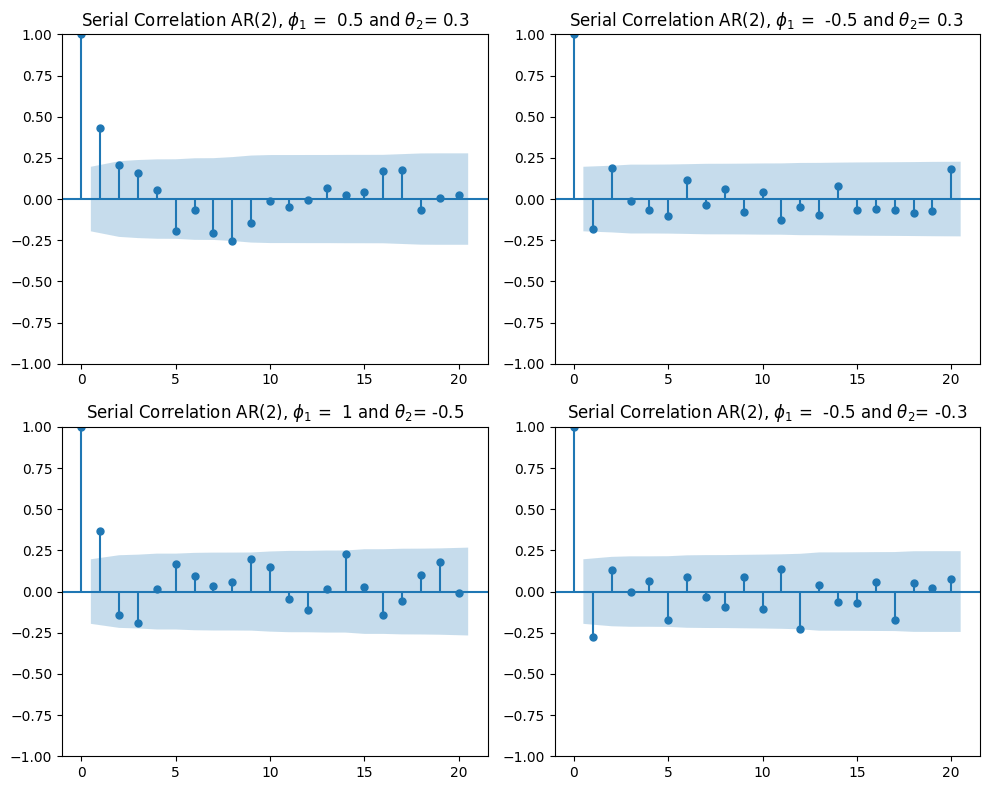

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

plot_acf(simulated_ar2_I_1, ax=ax[0, 0])
ax[0, 0].set_title("Serial Correlation AR(2), $\\phi_1$ =  0.5 and $\\theta_2$= 0.3")

plot_acf(simulated_ar2_II_1, ax=ax[0, 1])
ax[0, 1].set_title("Serial Correlation AR(2), $\\phi_1$ =  -0.5 and $\\theta_2$= 0.3 ")

plot_acf(simulated_ar2_III_1, ax=ax[1, 0])
ax[1, 0].set_title("Serial Correlation AR(2), $\\phi_1$ =  1 and $\\theta_2$= -0.5")

plot_acf(simulated_ar2_IV_1, ax=ax[1, 1])
ax[1, 1].set_title("Serial Correlation AR(2), $\\phi_1$ =  -0.5 and $\\theta_2$= -0.3")

plt.tight_layout()
plt.show()



The autocovariance functions exhibit exponential decay, with a possible sinusoidal variation superimposed.



***


#### Forecasting 

Further, the AR model as well as the MA can be used for forecasting, as we will show next using the full ARIMA model

In [1]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))